In [ ]:
!pip install -q joblib

In [ ]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Deep learning [RNN, GRU, LSTM] Neural Networks

In [ ]:
from PIL import Image

## Recurrent Neural Networks (RNN)

RNNs are a type of neural network designed for sequential data. They have loops in their architecture, allowing them to maintain a hidden state that captures information from previous inputs in a sequence. This makes them suitable for tasks like time series prediction, language modeling, and speech recognition. However, RNNs struggle with long-term dependencies due to the **vanishing gradient problem**.

---

## Gated Recurrent Unit (GRU)

GRU is an advanced version of RNN that introduces gating mechanisms to better manage long-term dependencies. It has two gates: **reset gate** and **update gate**. These gates control the flow of information, deciding what to keep from the past and what to discard. GRUs are computationally efficient and perform well on tasks with sequential data, often comparable to LSTMs but with fewer parameters.

---

## Long Short-Term Memory (LSTM)

LSTMs are another advanced form of RNN designed to handle long-term dependencies more effectively. LSTMs use three gates: **input gate**, **forget gate**, and **output gate**. These gates work together to regulate the flow of information, allowing LSTMs to remember important information over long sequences. LSTMs are widely used in tasks such as speech recognition, machine translation, and time series forecasting due to their ability to capture both short-term and long-term dependencies effectively.


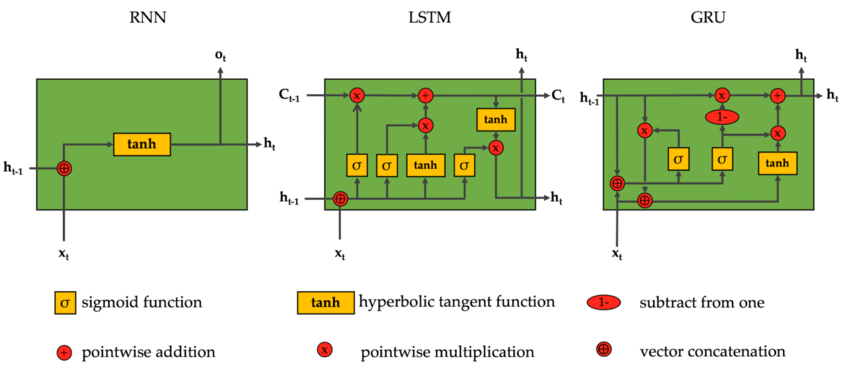

In [ ]:
img = Image. open('/content/drive/MyDrive/DACN3/Email-spam-classification-RNN-LSTM-GRU-main/RNNs-Arch.png')
display(img)

## GRU (Gated Recurrent Unit) Gates

1. **Reset Gate**:
   - The reset gate controls how much of the previous hidden state should be forgotten. It determines whether to reset or retain parts of the previous hidden state when processing the current input.
   - If the reset gate outputs a value close to 0, most of the previous information is discarded. If it outputs a value close to 1, more past information is retained.

2. **Update Gate**:
   - The update gate controls how much of the hidden state is passed to the next time step. It decides how much of the previous hidden state should carry over to the future.
   - A value close to 1 means most of the hidden state is retained, and a value close to 0 means most of the hidden state is replaced by the new information.

---

## LSTM (Long Short-Term Memory) Gates

1. **Input Gate**:
   - The input gate controls how much new information from the current input should be added to the cell state. It regulates the influence of the new input data on the memory.

2. **Forget Gate**:
   - The forget gate decides how much of the existing information in the cell state should be kept or discarded. It plays a crucial role in ensuring that irrelevant or outdated information is forgotten.

3. **Output Gate**:
   - The output gate controls how much of the information in the cell state should be used to compute the output of the current time step. It filters the cell state and passes relevant information as the hidden state.


# EMAIL SPAM CLASSIFICATION PROBLEM

### Load the required libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

# ======================================================
# TENSORFLOW / KERAS
# ======================================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras.models import Sequential

from keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from keras.callbacks import EarlyStopping

In [ ]:
import keras
print(keras.__version__)

3.13.2


### Data Exploring

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DACN3/thuylanh/Dataset/spam.csv')
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['Category'].value_counts()

,count
Category,
ham,4825
spam,747


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [ ]:
df.duplicated().sum()

np.int64(415)

In [ ]:
# df.duplicated().sum()

### Data preprocessing

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
encoder = LabelEncoder()
df['Category'] = encoder.fit_transform(df['Category'])
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['Message'])
sequences = tokenizer.texts_to_sequences(df['Message'])
max_len = max([len(seq) for seq in sequences])
X = pad_sequences(sequences, maxlen = max_len)
y = df['Category']

vocabs = len(tokenizer.word_index)+1
# vocabs

In [ ]:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)
# This cell is commented out as its content has been moved to the model training cell to resolve NameError.

### RNN Architecture

In [ ]:
rnn_model = Sequential([
    Embedding(vocabs, 64, input_length = max_len ),
    SimpleRNN(128),
    Dense(1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### LSTM Architecture

In [ ]:
lstm_model= Sequential([
    Embedding(vocabs, 64, input_length = max_len ),
    LSTM(128),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### GRU Architecture

In [ ]:
gru_model= Sequential([
    Embedding(vocabs, 64, input_length = max_len ),
    GRU(128),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### Define callbacks functions

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

rnn_cb = EarlyStopping(patience=5, restore_best_weights=True)
lstm_cb = EarlyStopping(patience=5, restore_best_weights=True)
gru_cb = EarlyStopping(patience=5, restore_best_weights=True)

### Train our models

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

print("-"*30, ' RNN ',"-"*30)
history_rnn = rnn_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=16, callbacks=rnn_cb)
print("-"*30, ' LSTM ',"-"*30)
history_lstm = lstm_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=16, callbacks=lstm_cb)
print("-"*30, ' GRU ',"-"*30)
history_gru = gru_model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=16, callbacks=gru_cb)

------------------------------  RNN  ------------------------------
Epoch 1/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8516 - loss: 0.3699 - val_accuracy: 0.8634 - val_loss: 0.3404
Epoch 2/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9239 - loss: 0.2066 - val_accuracy: 0.9477 - val_loss: 0.1482
Epoch 3/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9859 - loss: 0.0504 - val_accuracy: 0.9709 - val_loss: 0.0749
Epoch 4/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9976 - loss: 0.0162 - val_accuracy: 0.9709 - val_loss: 0.0744
Epoch 5/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9981 - loss: 0.0122 - val_accuracy: 0.9738 - val_loss: 0.0744
Epoch 6/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9983 - loss: 0.0089 - val_accuracy: 0.9806 - val_loss: 0.0724
Epoch 7/10
258/258 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9993 - loss: 0.0050 - val_accuracy: 0.9835 - val_loss: 0.0736
Epoch 8/10
258/258 ━━━━━━━━━━

In [ ]:
X_test

array([[   0,    0,    0, ...,    4,  121,  377],
       [   0,    0,    0, ...,    1,   19,   22],
       [   0,    0,    0, ...,    1,  148,  107],
       ...,
       [   0,    0,    0, ...,    1,  148,   72],
       [   0,    0,    0, ...,  400,    8, 1843],
       [   0,    0,    0, ...,    3,   85,   53]], dtype=int32)

### Test models

In [ ]:
y_pred_rnn = rnn_model.predict(X_test)
y_pred_lstm = lstm_model.predict(X_test)
y_pred_gru = gru_model.predict(X_test)

print("RNN Model Accuracy: ", accuracy_score(y_test, y_pred_rnn.round()))
print("LSTM Model Accuracy: ", accuracy_score(y_test, y_pred_lstm.round()))
print("GRU Model Accuracy: ", accuracy_score(y_test, y_pred_gru.round()))

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
RNN Model Accuracy:  0.9806201550387597
LSTM Model Accuracy:  0.9893410852713178
GRU Model Accuracy:  0.9903100775193798


In [ ]:
print(classification_report(y_test, y_pred_rnn.round()))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       896
           1       0.95      0.90      0.92       136

    accuracy                           0.98      1032
   macro avg       0.97      0.95      0.96      1032
weighted avg       0.98      0.98      0.98      1032



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

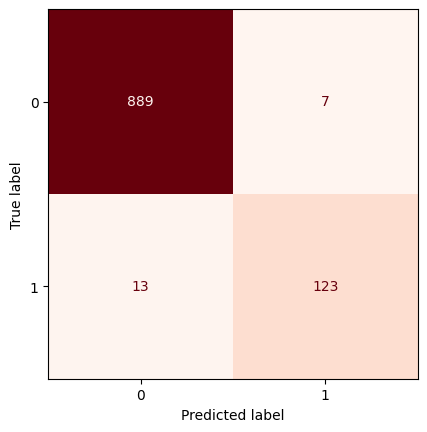

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_rnn.round())

# Create and plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot with default settings, or you can adjust parameters like colormap
disp.plot(cmap='Reds', colorbar=False, )

# Show the plot
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_lstm.round()))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       896
           1       0.99      0.93      0.96       136

    accuracy                           0.99      1032
   macro avg       0.99      0.96      0.98      1032
weighted avg       0.99      0.99      0.99      1032



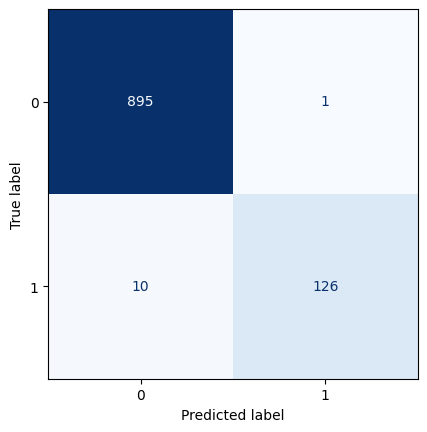

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_lstm.round())

# Create and plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot with default settings, or you can adjust parameters like colormap
disp.plot(cmap='Blues', colorbar=False)

# Show the plot
plt.show()

In [ ]:
print(classification_report(y_test, y_pred_gru.round()))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       896
           1       0.98      0.95      0.96       136

    accuracy                           0.99      1032
   macro avg       0.98      0.97      0.98      1032
weighted avg       0.99      0.99      0.99      1032



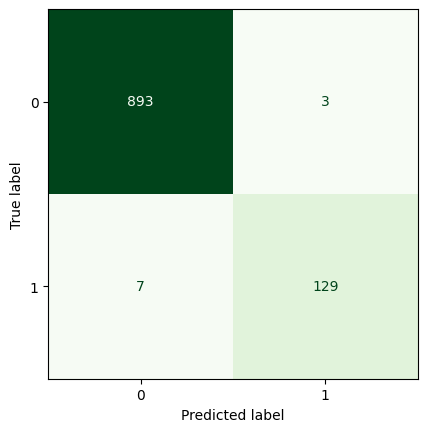

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_gru.round())

# Create and plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot with default settings, or you can adjust parameters like colormap
disp.plot(cmap='Greens', colorbar=False, )

# Show the plot
plt.show()

In [ ]:
def classify_email(text, rnn_model, lstm_model, gru_model, tokenizer, max_len):
    """
    Classifies the given email text as spam or ham using RNN, LSTM, and GRU models.

    Parameters:
    text (str): The email text to classify.
    rnn_model: Trained Simple RNN model.
    lstm_model: Trained LSTM model.
    gru_model: Trained GRU model.
    tokenizer: Fitted tokenizer for text preprocessing.
    max_len (int): Maximum sequence length for padding.

    Returns:
    dict: Classification results from all three models.
    """

    # Step 1: Preprocess the input text
    # Convert the text to sequences
    sequence = tokenizer.texts_to_sequences([text])
    # Pad the sequence to match the input length used in training
    padded_sequence = pad_sequences(sequence, maxlen=max_len)

    # Step 2: Make predictions using each model
    rnn_prediction = rnn_model.predict(padded_sequence)[0][0]
    lstm_prediction = lstm_model.predict(padded_sequence)[0][0]
    gru_prediction = gru_model.predict(padded_sequence)[0][0]

    # Step 3: Interpret the results
    results = {
        'Simple RNN Prediction': 'Spam' if rnn_prediction >= 0.5 else 'Ham',
        'LSTM Prediction': 'Spam' if lstm_prediction >= 0.5 else 'Ham',
        'GRU Prediction': 'Spam' if gru_prediction >= 0.5 else 'Ham',
        'Raw RNN Score': rnn_prediction,
        'Raw LSTM Score': lstm_prediction,
        'Raw GRU Score': gru_prediction
    }

    return results

# Example usage:
# Assuming tokenizer and max_len are already defined during training
# tokenizer = ... (fitted on the training data)
# max_len = ... (maximum length of padded sequences used during training)

email_text = "hello world"
classification_results = classify_email(email_text, rnn_model, lstm_model, gru_model, tokenizer, max_len)

print(classification_results)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
{'Simple RNN Prediction': 'Ham', 'LSTM Prediction': 'Ham', 'GRU Prediction': 'Ham', 'Raw RNN Score': np.float32(0.053659644), 'Raw LSTM Score': np.float32(0.0014395474), 'Raw GRU Score': np.float32(1.0423379e-05)}


# So sánh hiệu năng giữa các mô hình
# Tự động chọn mô hình tốt nhất
# Lưu model theo dạng dùng được ở front-end

In [ ]:
results = []

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

for name, model in models.items():
    y_pred = model.predict(X_test).round()
    acc = accuracy_score(y_test, y_pred)

    report = classification_report(y_test, y_pred, output_dict=True)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-score": report['weighted avg']['f1-score']
    })

df_results = pd.DataFrame(results)
print(df_results)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
  Model  Accuracy  Precision    Recall  F1-score
0   RNN  0.980620   0.980391  0.980620  0.980434
1  LSTM  0.989341   0.989369  0.989341  0.989185
2   GRU  0.990310   0.990252  0.990310  0.990249


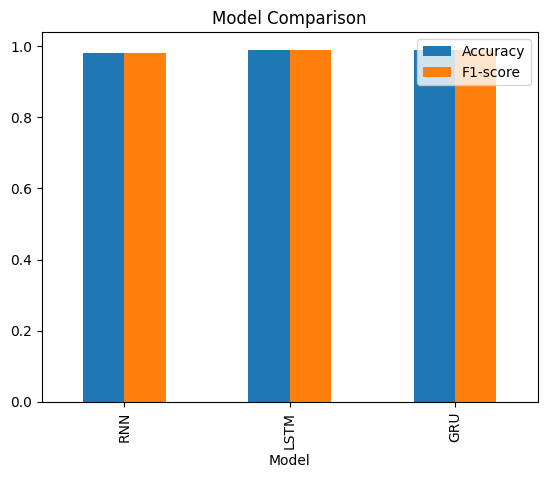

In [ ]:
df_results.set_index("Model")[["Accuracy","F1-score"]].plot(kind="bar")
plt.title("Model Comparison")
plt.show()

In [ ]:
best_model_row = df_results.loc[df_results['F1-score'].idxmax()]
best_model_name = best_model_row['Model']

print("Best model:", best_model_name)


Best model: GRU


In [ ]:
best_model = models[best_model_name]

In [ ]:
import json
import joblib

SAVE_FOLDER = '/content/drive/MyDrive/DACN3/Model_Ha/21_5/'

# =========================================================
# 1. SAVE FULL MODEL (.keras)
# =========================================================

best_model.save(
    SAVE_FOLDER + 'sms_best_model.keras'
)

print("✅ Full model (.keras) saved!")

# =========================================================
# 2. SAVE TOKENIZER
# =========================================================

joblib.dump(
    tokenizer,
    SAVE_FOLDER + 'sms_tokenizer.pkl'
)

print("✅ Tokenizer saved!")

# =========================================================
# 3. SAVE LABEL ENCODER
# =========================================================

joblib.dump(
    encoder,
    SAVE_FOLDER + 'sms_label_encoder.pkl'
)

print("✅ Label encoder saved!")

# =========================================================
# 4. SAVE MODEL CONFIG
# =========================================================

model_config = {

    # Text preprocessing
    "max_len": int(max_len),
    "vocab_size": int(vocabs),

    # Model architecture
    "embedding_dim": 64,
    "units": 128,
    "dropout_rate": 0.2,

    # Training info
    "model_type": best_model_name,
    "loss": "binary_crossentropy",
    "optimizer": "adam",

    # Prediction threshold
    "spam_threshold": 0.5
}

# =========================================================
# 5. SAVE CONFIG JSON
# =========================================================

with open(
    SAVE_FOLDER + 'model_config.json',
    'w'
) as f:

    json.dump(
        model_config,
        f,
        indent=4
    )

print("✅ Model config saved!")

✅ Full model (.keras) saved!
✅ Tokenizer saved!
✅ Label encoder saved!
✅ Model config saved!


In [ ]:
import tensorflow as tf
import keras

print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2


In [ ]:
test_email = "Congratulations! You've won a free iPhone. Click here to claim your prize!"

# Use the classify_email function with the test email and the best model (GRU)
classification_results = classify_email(test_email, rnn_model, lstm_model, gru_model, tokenizer, max_len)

print(f"Test Email: '{test_email}'")
print(f"Best Model ({best_model_name}) Prediction: {classification_results[f'{best_model_name} Prediction']} (Raw Score: {classification_results[f'Raw {best_model_name} Score']:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Test Email: 'Congratulations! You've won a free iPhone. Click here to claim your prize!'
Best Model (GRU) Prediction: Spam (Raw Score: 0.9995)
